# Lab 4, Day 2 — Fashion-MNIST Classification

Build a classifier with proper validation tracking and early stopping, then read a
confusion matrix as an error-analysis tool rather than decoration. See
`Lab4_Day2_Instructions.md` for the full walkthrough.

This notebook is just a shell: the data loading, model, training loop, and analysis
are yours to write.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from stage_b_classification import load_fn

## Step 1: Load Fashion-MNIST and prepare loaders (`stage_b_classification.py`)

In [2]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, TensorDataset, random_split

transform = transforms.ToTensor()
train_full = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_set = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_size = int(0.7 * len(train_full))
val_size = len(train_full) - train_size

train_set, val_set = random_split(
    train_full,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(0)
)

print("Training images:", len(train_set))
print("Validation images:", len(val_set))
print("Test images:", len(test_set))
print("Classes:", train_full.classes)


Training images: 42000
Validation images: 18000
Test images: 10000
Classes: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## Look at the data before you model it

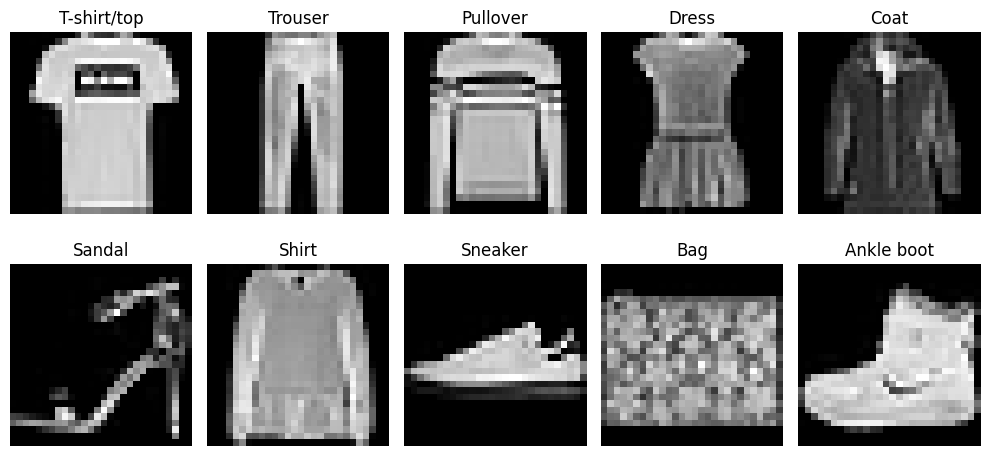

In [3]:
# TODO: plot a handful of example images, one (or a few) per class - use
# train_set.classes for the human-readable label names. This is worth doing before
# you build anything: you will be asked later whether the confusion matrix's mistakes
# are reasonable, and you cannot judge that without having actually looked at the images.
train_loader = load_fn(train_set)
test_loader = load_fn(test_set)
val_loader = load_fn(val_set)

fig, axes = plt.subplots(2, 5, figsize=(10, 5))

for i in range(10):
    for image, label in train_full:
        if label == i:
            axes[i // 5, i % 5].imshow(image.squeeze(), cmap="gray")
            axes[i // 5, i % 5].set_title(train_full.classes[i])
            axes[i // 5, i % 5].axis("off")
            break

plt.tight_layout()
plt.show()

## Step 2: The classifier

In [4]:
# TODO: Flatten -> Linear -> ReLU -> Linear (10 classes), raw scores, NO softmax -
# CrossEntropyLoss applies it internally
from stage_b_classification import build_mlp_img
model = build_mlp_img()
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    model.parameters(),
    lr=0.01
)

## Step 3: Train with validation tracking and early stopping

In [6]:
# TODO: train_with_early_stopping (or write it yourself) - track train loss and val
# accuracy per epoch, patience-based stopping (not a single bad epoch), .clone() the
# best state_dict before restoring it
from train import train_full_loader
train_loss, val_acc = train_full_loader(train_loader, val_loader, model, lr=1e-3, epochs=100)

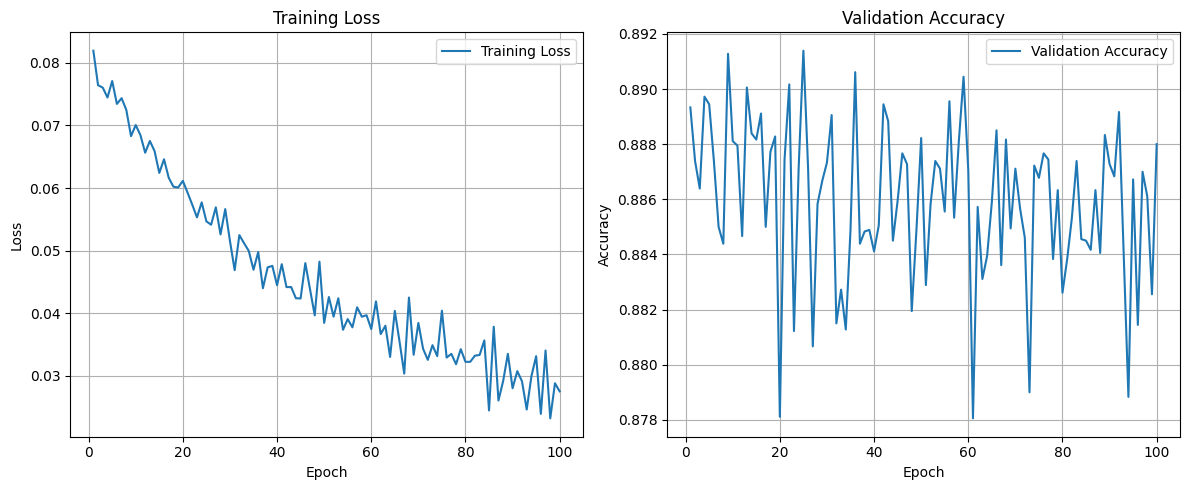

In [7]:
# TODO: plot training loss and validation accuracy curves, report test accuracy
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Training loss
axes[0].plot(
    range(1, len(train_loss) + 1),
    train_loss,
    label="Training Loss"
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training Loss")
axes[0].legend()
axes[0].grid(True)

# Validation accuracy
axes[1].plot(
    range(1, len(val_acc) + 1),
    val_acc,
    label="Validation Accuracy"
)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Validation Accuracy")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

In [8]:
all_predictions = []
all_labels = []
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for X, y in test_loader:

        X = X.to(device="cpu")
        y = y.to(device="cpu")
        outputs = model(X)
        predictions = torch.argmax(outputs, dim=1)
        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(y.numpy())
        correct += (predictions == y).sum().item()
        total += y.size(0)

test_accuracy = correct / total

print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

Test Accuracy: 88.04%


## Step 4: Confusion matrix

In [9]:
# TODO: confusion matrix on the test set - which classes get confused, and does that
# make sense given what those classes actually look like?
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(
    all_labels,
    all_predictions
)
print(cm)

[[841   1  18  16   8   1 106   0   9   0]
 [  5 977   0  13   2   0   2   0   1   0]
 [ 20   1 822  14  74   1  62   1   5   0]
 [ 37  11  11 866  34   1  36   0   4   0]
 [  1   0  96  24 812   0  61   0   6   0]
 [  1   0   0   1   0 959   0  25   2  12]
 [133   2  87  23  74   1 661   1  18   0]
 [  0   0   0   0   0  17   0 952   1  30]
 [  5   1   6   5   1   1   6   4 971   0]
 [  0   0   0   2   0  10   1  44   0 943]]


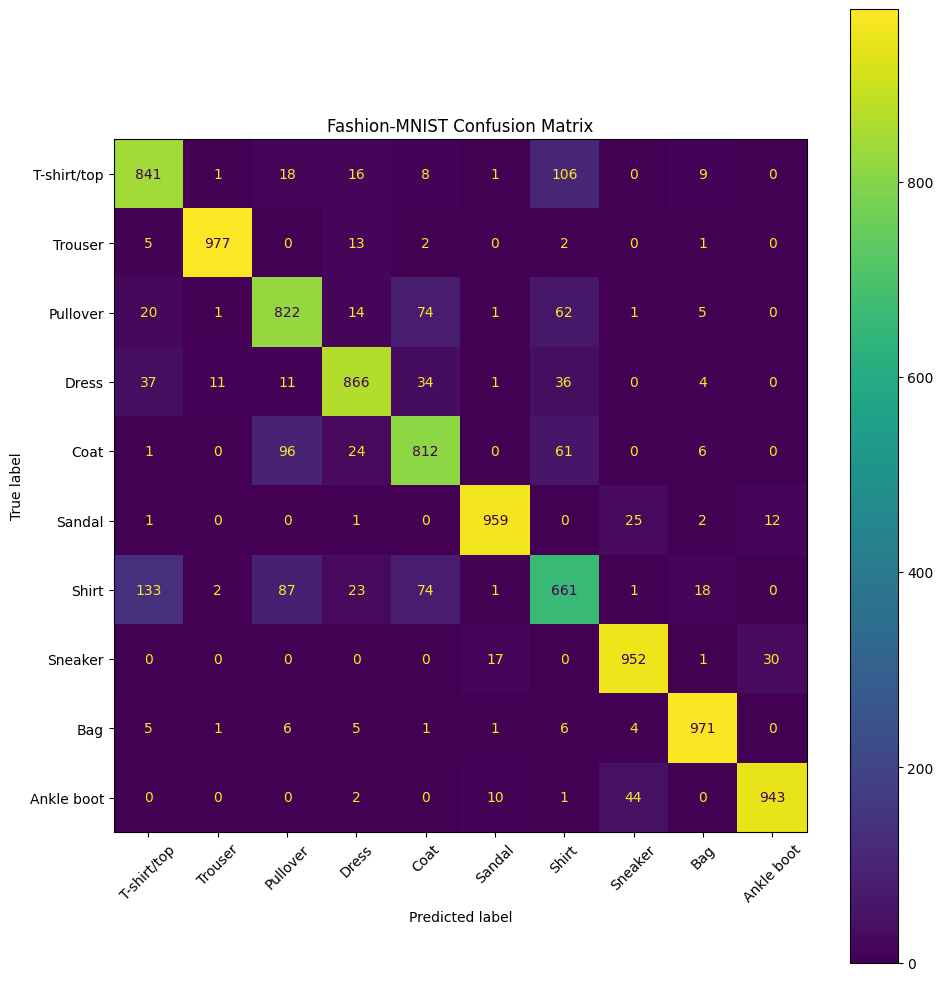

In [10]:
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels= train_full.classes
)

fig, ax = plt.subplots(figsize=(10, 10))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.title("Fashion-MNIST Confusion Matrix")
plt.tight_layout()
plt.show()

### Written prompt

In that gap the model is overfitting. It keeps lowering training loss by memorizing the training images instead of learning patterns that generalize, which is why validation accuracy stops improving. Early stopping rule prevented this. It saved the weights from the epoch with the best validation accuracy and stopped once accuracy stopped improving, so I kept the model that generalizes best instead of the over memorized one.

### Closing reflection

PyTorch computed the gradients since one call to loss.backward() worked out every derivative through the network, which is impossible to do by hand once there is more than one layer. What it did not do was make important decisions about hyperparameters. I still had to keep the validation set separate, choose the architecture and learning rate, and decide when to stop.